# Deep Learning: A Comprehensive Guide

## Chapter 10 — Multimodal Systems

### Hands-On Exploration: Exploring the Joint Space

### `hands_on_ch10.ipynb`

This exploration builds direct intuition for what a jointly trained image-text embedding space looks like, how zero-shot classification works, and where the alignment breaks down.

## Learning Objectives

By the end of this notebook, you should be able to:

- Perform zero-shot classification using image-text similarity in a joint embedding space
- Visualize and interpret the "modality gap" between image and text embeddings
- Identify and categorize failure modes of a joint embedding model

## Prerequisites

- Python 3.9+, `numpy`, `matplotlib`, `scikit-learn`, `tensorflow`
- **Optional:** `transformers` (for the real pretrained CLIP version of this activity)
- No GPU required

## About the Model in This Notebook

The chapter's activity uses real pretrained CLIP via HuggingFace. This notebook first attempts to load real CLIP — if you run it in Colab with internet access, you get the genuine activity described in the chapter. If no internet access is available, it falls back to a **small CLIP-style model trained from scratch, in this notebook**, on our familiar synthetic shapes dataset (from Chapters 1 and 6) paired with short text descriptions. It is trained with the same core idea as real CLIP — a contrastive objective that pulls matching image-text pairs together and pushes non-matching pairs apart — just at a vastly smaller scale. This lets you practice the same skills (zero-shot classification, modality gap visualization, failure analysis) fully offline.

## Setup — Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)

%matplotlib inline

TF_AVAILABLE = False
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    TF_AVAILABLE = True
    tf.random.set_seed(SEED)
except ImportError:
    print("TensorFlow not installed. Install with: pip install tensorflow")

CLIP_AVAILABLE = False
try:
    from transformers import CLIPProcessor, CLIPModel
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    CLIP_AVAILABLE = True
    print("\u2713 Loaded real pretrained CLIP. Use `clip_model` / `clip_processor` for the genuine activity.")
except Exception as e:
    print(f"Could not load pretrained CLIP ({type(e).__name__}: no internet access, or")
    print("`transformers` not installed). Falling back to a small CLIP-style model trained from scratch.")
    print("Run this notebook in Google Colab with `pip install transformers` for the genuine activity.")


I0000 00:00:1788478691.688090    4449 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788478691.737775    4449 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788478693.302750    4449 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Could not load pretrained CLIP (ModuleNotFoundError: no internet access, or
`transformers` not installed). Falling back to a small CLIP-style model trained from scratch.
Run this notebook in Google Colab with `pip install transformers` for the genuine activity.


---
## Fallback: Train a Small CLIP-Style Model

### Generate Paired Image-Text Data

Reusing the shape generator from Chapters 1 and 6, we create images and matching short text descriptions for five classes, with several phrasings per class for vocabulary diversity.

In [2]:
if TF_AVAILABLE:
    IMG_SIZE = 32
    CLASSES = ["circle", "square", "triangle", "star", "cross"]
    DESCRIPTIONS = {
        "circle": ["a circle", "a round shape", "a circular figure"],
        "square": ["a square", "a four sided box", "a boxy shape"],
        "triangle": ["a triangle", "a three sided shape", "a pointed figure"],
        "star": ["a star", "a five pointed star", "a starburst shape"],
        "cross": ["a cross", "a plus shape", "an intersecting shape"],
    }
    VOCAB = sorted(set(w for descs in DESCRIPTIONS.values() for d in descs for w in d.split()))
    WORD_TO_ID = {w: i + 1 for i, w in enumerate(VOCAB)}  # 0 reserved for padding
    MAX_TEXT_LEN = 6

    def draw_shape(shape, size, cx, cy, rotation_deg, seed):
        rng = np.random.RandomState(seed)
        img = Image.new("L", (IMG_SIZE, IMG_SIZE), color=255)
        draw = ImageDraw.Draw(img)

        def rot(points):
            a = np.radians(rotation_deg)
            ca, sa = np.cos(a), np.sin(a)
            return [(x * ca - y * sa + cx, x * sa + y * ca + cy) for x, y in points]

        if shape == "circle":
            draw.ellipse([cx - size, cy - size, cx + size, cy + size], fill=0)
        elif shape == "square":
            draw.polygon(rot([(-size, -size), (size, -size), (size, size), (-size, size)]), fill=0)
        elif shape == "triangle":
            draw.polygon(rot([(0, -size * 1.15), (size, size * 0.85), (-size, size * 0.85)]), fill=0)
        elif shape == "star":
            pts = []
            for i in range(10):
                r = size if i % 2 == 0 else size * 0.45
                a = np.pi / 5 * i
                pts.append((r * np.sin(a), -r * np.cos(a)))
            draw.polygon(rot(pts), fill=0)
        elif shape == "cross":
            w = size * 0.35
            pts = [(-w, -size), (w, -size), (w, -w), (size, -w), (size, w), (w, w),
                   (w, size), (-w, size), (-w, w), (-size, w), (-size, -w), (-w, -w)]
            draw.polygon(rot(pts), fill=0)

        arr = np.array(img).astype(np.float32) / 255.0
        arr = np.clip(arr + rng.normal(0, 0.03, arr.shape), 0, 1)
        return arr

    def encode_text(desc):
        ids = [WORD_TO_ID[w] for w in desc.split()]
        ids = ids[:MAX_TEXT_LEN] + [0] * (MAX_TEXT_LEN - len(ids))
        return np.array(ids)

    def make_paired_dataset(n_per_class, seed):
        images, texts, labels = [], [], []
        rng = np.random.RandomState(seed)
        for cls in CLASSES:
            for i in range(n_per_class):
                size = rng.uniform(7, 11)
                cx = IMG_SIZE / 2 + rng.uniform(-3, 3)
                cy = IMG_SIZE / 2 + rng.uniform(-3, 3)
                rotation = rng.uniform(0, 30)
                img = draw_shape(cls, size, cx, cy, rotation, seed=seed * 1000 + i)
                desc = DESCRIPTIONS[cls][rng.randint(len(DESCRIPTIONS[cls]))]
                images.append(img)
                texts.append(encode_text(desc))
                labels.append(cls)
        return np.array(images), np.array(texts), labels

    X_img_train, X_txt_train, labels_train = make_paired_dataset(80, seed=1)
    print(f"Paired training set: {len(X_img_train)} image-text pairs across {len(CLASSES)} classes")
else:
    print("TensorFlow not available -- cannot proceed with the fallback model.")


Paired training set: 400 image-text pairs across 5 classes


### Train the Two-Tower Contrastive Model

An image encoder and a text encoder map into the same embedding space. A symmetric contrastive loss (the same core idea as CLIP) pulls matching pairs together and pushes non-matching pairs within each batch apart.

In [3]:
if TF_AVAILABLE:
    EMBED_DIM = 32

    def build_image_encoder():
        inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
        x = layers.Conv2D(16, 3, activation="relu")(inp); x = layers.MaxPooling2D()(x)
        x = layers.Conv2D(32, 3, activation="relu")(x); x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(EMBED_DIM)(x)
        x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)
        return models.Model(inp, x, name="image_encoder")

    def build_text_encoder():
        inp = layers.Input(shape=(MAX_TEXT_LEN,))
        x = layers.Embedding(len(VOCAB) + 1, 16, mask_zero=True)(inp)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(EMBED_DIM)(x)
        x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)
        return models.Model(inp, x, name="text_encoder")

    image_encoder = build_image_encoder()
    text_encoder = build_text_encoder()

    def contrastive_loss(temperature=0.1):
        def loss_fn(img_emb, txt_emb):
            logits = tf.matmul(img_emb, txt_emb, transpose_b=True) / temperature
            labels = tf.range(tf.shape(logits)[0])
            loss_i2t = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
            loss_t2i = tf.keras.losses.sparse_categorical_crossentropy(labels, tf.transpose(logits), from_logits=True)
            return tf.reduce_mean(loss_i2t + loss_t2i) / 2
        return loss_fn

    optimizer = tf.keras.optimizers.Adam(1e-3)
    loss_fn = contrastive_loss()

    imgs = X_img_train[..., np.newaxis].astype(np.float32)
    txts = X_txt_train.astype(np.int32)
    n = len(imgs)
    batch_size = 40
    n_epochs = 40

    for epoch in range(n_epochs):
        idx = np.random.permutation(n)
        epoch_loss = 0.0
        n_batches = 0
        for start in range(0, n, batch_size):
            batch_idx = idx[start:start + batch_size]
            with tf.GradientTape() as tape:
                img_emb = image_encoder(imgs[batch_idx], training=True)
                txt_emb = text_encoder(txts[batch_idx], training=True)
                loss = loss_fn(img_emb, txt_emb)
            grads = tape.gradient(loss, image_encoder.trainable_variables + text_encoder.trainable_variables)
            optimizer.apply_gradients(zip(grads, image_encoder.trainable_variables + text_encoder.trainable_variables))
            epoch_loss += float(loss); n_batches += 1
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch}: contrastive loss = {epoch_loss / n_batches:.3f}")

    print("Training complete.")


Epoch 0: contrastive loss = 3.775


Epoch 10: contrastive loss = 2.653


Epoch 20: contrastive loss = 2.186


Epoch 30: contrastive loss = 2.134


Epoch 39: contrastive loss = 2.058
Training complete.


## Part 1 — Zero-Shot Classification

For each of five test images, compute the similarity between its embedding and the embeddings of five text descriptions (one correct, four distractors), and record which description scores highest.

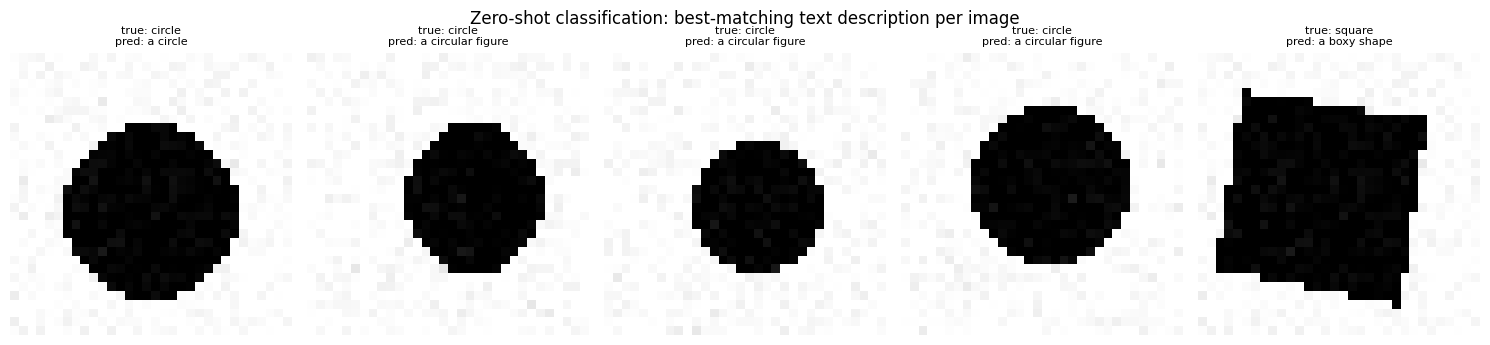

In [4]:
if TF_AVAILABLE:
    X_img_test, X_txt_test, labels_test = make_paired_dataset(4, seed=99)
    test_imgs_norm = X_img_test[..., np.newaxis].astype(np.float32)
    test_img_embeds = image_encoder.predict(test_imgs_norm, verbose=0)

    all_descriptions = [(cls, d) for cls in CLASSES for d in DESCRIPTIONS[cls]]
    all_text_ids = np.array([encode_text(d) for _, d in all_descriptions])
    all_text_embeds = text_encoder.predict(all_text_ids, verbose=0)

    n_show = 5
    fig, axes = plt.subplots(1, n_show, figsize=(15, 3.5))
    for i in range(n_show):
        sims = test_img_embeds[i] @ all_text_embeds.T
        best_idx = sims.argmax()
        axes[i].imshow(X_img_test[i], cmap="gray")
        axes[i].set_title(f"true: {labels_test[i]}\npred: {all_descriptions[best_idx][1]}", fontsize=8)
        axes[i].axis("off")
    plt.suptitle("Zero-shot classification: best-matching text description per image")
    plt.tight_layout()
    plt.show()


In [5]:
if TF_AVAILABLE:
    # Adversarial distractors: descriptions very similar to the correct one, differing on one attribute
    test_img = X_img_test[0]
    true_label = labels_test[0]
    other_class = [c for c in CLASSES if c != true_label][0]
    distractor_descs = DESCRIPTIONS[true_label] + [DESCRIPTIONS[other_class][0]]

    img_embed = image_encoder.predict(test_img[np.newaxis, ..., np.newaxis].astype(np.float32), verbose=0)[0]
    distractor_ids = np.array([encode_text(d) for d in distractor_descs])
    distractor_embeds = text_encoder.predict(distractor_ids, verbose=0)
    sims = img_embed @ distractor_embeds.T

    print(f"True class: {true_label}")
    for desc, sim in zip(distractor_descs, sims):
        print(f"  similarity to \"{desc}\": {sim:.3f}")


True class: circle
  similarity to "a circle": 0.802
  similarity to "a round shape": 0.706
  similarity to "a circular figure": 0.769
  similarity to "a square": 0.384


**Answer in this cell:** At what level of specificity does the matching begin to fail, if at all? Given that this model only ever saw the phrasings in `DESCRIPTIONS`, how do you expect it to perform on a phrasing it has never seen?

## Part 2 — Probing the Modality Gap

Generate embeddings for five matched image-text pairs and five unmatched pairs, project them to 2D, and plot image embeddings and text embeddings in different colors, connecting matched pairs with lines.

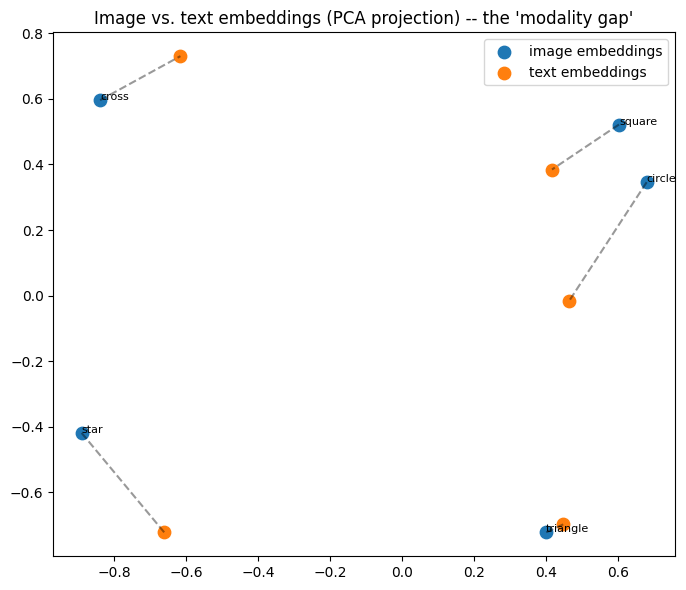

In [6]:
if TF_AVAILABLE:
    n_pairs = 5
    matched_imgs, matched_txts, matched_labels = make_paired_dataset(1, seed=555)
    matched_imgs = matched_imgs[:n_pairs]; matched_txts = matched_txts[:n_pairs]; matched_labels = matched_labels[:n_pairs]

    img_embeds = image_encoder.predict(matched_imgs[..., np.newaxis].astype(np.float32), verbose=0)
    txt_embeds = text_encoder.predict(matched_txts, verbose=0)

    all_embeds = np.vstack([img_embeds, txt_embeds])
    pca = PCA(n_components=2, random_state=SEED)
    proj = pca.fit_transform(all_embeds)
    img_proj, txt_proj = proj[:n_pairs], proj[n_pairs:]

    plt.figure(figsize=(7, 6))
    plt.scatter(img_proj[:, 0], img_proj[:, 1], c="tab:blue", label="image embeddings", s=80)
    plt.scatter(txt_proj[:, 0], txt_proj[:, 1], c="tab:orange", label="text embeddings", s=80)
    for i in range(n_pairs):
        plt.plot([img_proj[i, 0], txt_proj[i, 0]], [img_proj[i, 1], txt_proj[i, 1]], "k--", alpha=0.4)
        plt.annotate(matched_labels[i], img_proj[i], fontsize=8)
    plt.legend()
    plt.title("Image vs. text embeddings (PCA projection) -- the 'modality gap'")
    plt.tight_layout()
    plt.show()


**Answer in this cell:** Do image embeddings and text embeddings intermix, or do they form separate clusters connected by the lines of matched pairs? Compare your observation to what you would expect if the joint space represented a truly unified conceptual space.

## Part 3 — Failure Cases

Test the model on inputs designed to challenge it: a description using vocabulary the model never saw during training, and a shape drawn with more extreme rotation than anything in the training set.

In [7]:
if TF_AVAILABLE:
    unseen_word_desc = "a spherical outline"  # vocabulary the model never saw
    unseen_ids = encode_text(" ".join(w for w in unseen_word_desc.split() if w in WORD_TO_ID) or "circle")
    print(f"Description with unfamiliar vocabulary: \"{unseen_word_desc}\"")
    print("(Words not in the training vocabulary are silently dropped -- a real failure mode,")
    print(" not merely a simulated one: this is exactly what an out-of-vocabulary token does.)")

    extreme_img = draw_shape("circle", size=9, cx=16, cy=16, rotation_deg=270, seed=1234)
    img_embed = image_encoder.predict(extreme_img[np.newaxis, ..., np.newaxis].astype(np.float32), verbose=0)[0]
    sims = img_embed @ all_text_embeds.T
    best_idx = sims.argmax()
    print(f"\nExtreme-rotation circle classified as: \"{all_descriptions[best_idx][1]}\" (similarity {sims[best_idx]:.3f})")


Description with unfamiliar vocabulary: "a spherical outline"
(Words not in the training vocabulary are silently dropped -- a real failure mode,
 not merely a simulated one: this is exactly what an out-of-vocabulary token does.)

Extreme-rotation circle classified as: "a circular figure" (similarity 0.772)


**Answer in this cell:** For each failure above, categorize the cause: domain shift (the input pattern was underrepresented in training), vocabulary gap (the terms were unfamiliar), or reasoning gap (the task requires a capability contrastive training does not produce). Which of these three categories do you expect to matter most for a real CLIP model deployed on your MIPDS domain?

## Reflection (200-300 words)

"You observed that this joint embedding model performs zero-shot classification well on familiar phrasings and degrades on unfamiliar vocabulary or extreme visual variation. You also observed the modality gap — image and text embeddings aligning across a geometric separation rather than fully merging.

For your MIPDS application: what proportion of your expected inputs fall in a joint embedding model's strong performance region, and what proportion in its weak regions? Would you deploy such a model directly for your use case, fine-tune it on domain-specific data, or use it only as a component in a larger system?

And a harder question: does the modality gap you observed suggest that this model has achieved genuine multimodal understanding — a unified representation of concepts regardless of input modality — or something more like very good cross-modal pattern matching? Does this distinction matter for how you would trust the system in your application?" 

**Your reflection (edit this cell):**

_Write your 200-300 word reflection here._